# Advanced Statistics Project: ANOVA & Principal Component Analysis
**Author:** Himani Kamra | PGP-DSBA, Great Lakes Executive Learning

This notebook contains two independent statistical analyses:
1. **Problem 1 — ANOVA:** Testing whether Education and Occupation affect Salary (one-way and two-way ANOVA with interaction effects)
2. **Problem 2 — PCA:** Reducing dimensionality of a 777-university admissions dataset using Principal Component Analysis


## Problem 1: ANOVA on Salary

**Business context:** Salary is hypothesized to depend on educational qualification and occupation. Salaries of 40 individuals were collected along with their Education level (High School Graduate, Bachelor, Doctorate) and Occupation (Admin-clerical, Sales, Prof-specialty, Exec-managerial).

**Data attributes:**
- `Education`: educational qualification
- `Occupation`: job category
- `Salary`: continuous, range 50,103 – 260,151


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import _get_covariance,anova_lm

In [63]:
df=pd.read_csv("SalaryData.csv")

In [64]:
df.describe()

,Salary
count,40.000000
mean,162186.875000
std,64860.407506
min,50103.000000
25%,99897.500000
50%,169100.000000
75%,214440.750000
max,260151.000000


In [65]:
df.shape

(40, 3)

In [5]:
df.head()

,Education,Occupation,Salary
0,Doctorate,Adm-clerical,153197
1,Doctorate,Adm-clerical,115945
2,Doctorate,Adm-clerical,175935
3,Doctorate,Adm-clerical,220754
4,Doctorate,Sales,170769


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Education   40 non-null     object
 1   Occupation  40 non-null     object
 2   Salary      40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB


### One-Way ANOVA: Does Education affect Salary?

**H₀:** mean salary is the same for all education levels

**Hₐ:** mean salary differs for at least one education level

Significance level (α) = 0.05

In [7]:
formula="Salary~C(Education)"
model=ols(formula,df).fit()
aov_table=anova_lm(model)
print(aov_table)

                df        sum_sq       mean_sq         F        PR(>F)
C(Education)   2.0  1.026955e+11  5.134773e+10  30.95628  1.257709e-08
Residual      37.0  6.137256e+10  1.658718e+09       NaN           NaN


**Result:** p-value = 1.26e-08, which is well below α = 0.05 → **reject H₀**. Mean salary is not the same across education levels — education has a statistically significant effect on salary.

### One-Way ANOVA: Does Occupation affect Salary?

**H₀:** mean salary is the same for every occupation

**Hₐ:** mean salary differs for at least one occupation

In [9]:
formula1="Salary~C(Occupation)"
model=ols(formula1,df).fit()
aov_table=anova_lm(model)
print(aov_table)

                 df        sum_sq       mean_sq         F    PR(>F)
C(Occupation)   3.0  1.125878e+10  3.752928e+09  0.884144  0.458508
Residual       36.0  1.528092e+11  4.244701e+09       NaN       NaN


**Result:** p-value = 0.459, greater than α = 0.05 → **fail to reject H₀**. On its own, occupation does not have a statistically significant effect on salary.

### Interaction Effect: Education × Occupation

Before running the two-way ANOVA, an interaction plot helps visualize whether the effect of Education on Salary depends on Occupation (i.e., whether the lines cross/diverge).

<AxesSubplot:xlabel='Occupation', ylabel='Salary'>

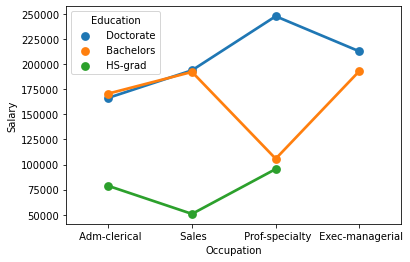

In [14]:
sns.pointplot(x="Occupation",y="Salary",data=df,hue="Education",ci=None)

The plot shows the lines for each education level moving differently across occupations — suggesting a possible interaction effect, which the two-way ANOVA below tests formally.

### Two-Way ANOVA (with interaction term)

**H₀:** there is no interaction effect of education and occupation on salary

**Hₐ:** there is an interaction effect of education and occupation on salary

In [13]:
#two-way anova
formula2="Salary~C(Education)+C(Occupation)+C(Education):C(Occupation)"
model=ols(formula2,df).fit()
aov_table=anova_lm(model)
print(aov_table)

                              df        sum_sq       mean_sq          F  \
C(Education)                 2.0  1.026955e+11  5.134773e+10  72.211958   
C(Occupation)                3.0  5.519946e+09  1.839982e+09   2.587626   
C(Education):C(Occupation)   6.0  3.634909e+10  6.058182e+09   8.519815   
Residual                    29.0  2.062102e+10  7.110697e+08        NaN   

                                  PR(>F)  
C(Education)                5.466264e-12  
C(Occupation)               7.211580e-02  
C(Education):C(Occupation)  2.232500e-05  
Residual                             NaN  


**Result:** interaction p-value = 2.23e-05 (< 0.05) → **reject H₀**. Salary is affected by education and occupation *simultaneously* — the two factors interact.

**Business implications:**
1. Salary is affected by education level — high school graduates, bachelor's, and doctorate holders earn differently.
2. Occupation alone does not significantly affect salary, but occupation *combined with* education does, due to a significant interaction effect — i.e., the salary premium for a given education level depends on the occupation it's paired with.

---
## Problem 2: Principal Component Analysis (PCA)

**Business context:** The dataset contains admissions and financial data for 777 US colleges/universities (applications, acceptance, enrollment, tuition, faculty stats, etc.). With 17 numeric features, many of which are correlated, PCA is used to reduce dimensionality while retaining most of the information — useful before further modelling (e.g. clustering or regression on college performance).

**Key attributes:** Apps, Accept, Enroll, Top10perc, Top25perc, F.Undergrad, P.Undergrad, Outstate, Room.Board, Books, Personal, PhD, Terminal, S.F.Ratio, perc.alumni, Expend, Grad.Rate (777 rows, 18 columns, no missing values).

In [4]:
df1=pd.read_csv("Education+-+Post+12th+Standard.csv")

In [5]:
df1.head()

,Names,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [68]:
df1.Names.value_counts

<bound method IndexOpsMixin.value_counts of 0        Abilene Christian University
1                  Adelphi University
2                      Adrian College
3                 Agnes Scott College
4           Alaska Pacific University
                    ...              
772           Worcester State College
773                 Xavier University
774    Xavier University of Louisiana
775                   Yale University
776      York College of Pennsylvania
Name: Names, Length: 777, dtype: object>

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Names        777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int64(16), object(1)
memory usage: 

In [47]:
df1.shape

(777, 18)

### Exploratory Data Analysis — Univariate
Distribution of each numeric variable, checked for skew and shape.

In [9]:
def univariateanalysis_numeric(column,nbins):
    plt.figure()
    sns.histplot(df1[column],kde=False,color="b");
    print("Distribution of"+column)
    plt.show()
    

Distribution ofApps


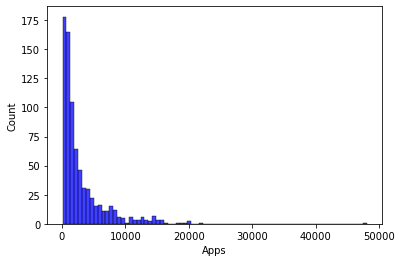

In [10]:
univariateanalysis_numeric("Apps",20)

In [12]:
df1_num=df1.select_dtypes(include=["float64","int64"])
numericcolumns=list(df1_num.columns.values)
len(numericcolumns)

17

In [13]:
df1_num.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


Distribution ofApps


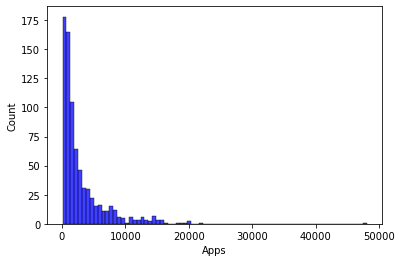

Distribution ofAccept


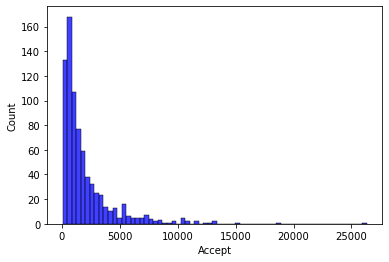

Distribution ofEnroll


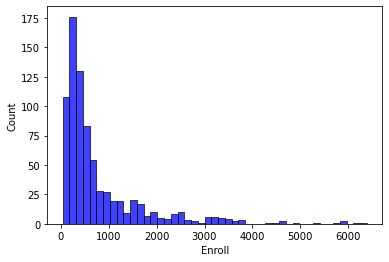

Distribution ofTop10perc


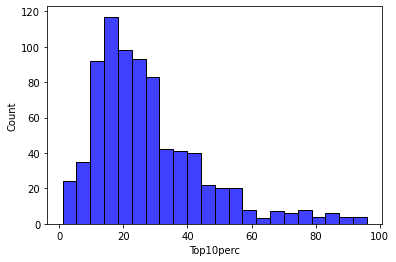

Distribution ofTop25perc


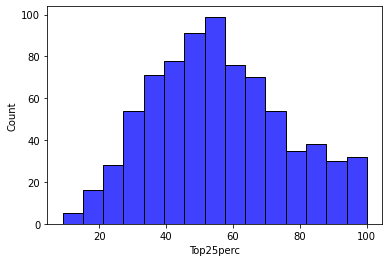

Distribution ofF.Undergrad


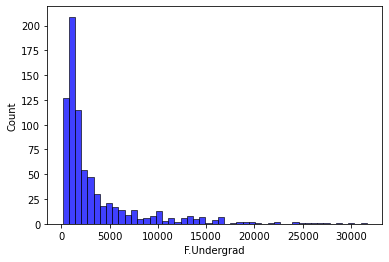

Distribution ofP.Undergrad


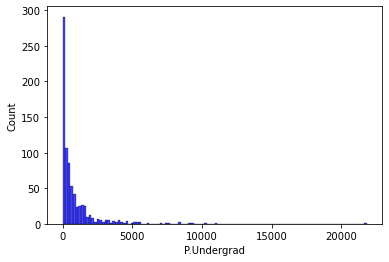

Distribution ofOutstate


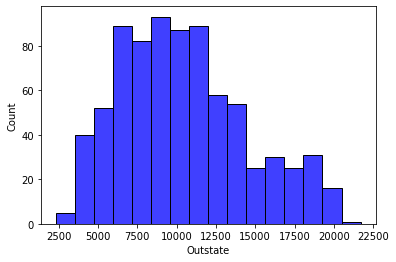

Distribution ofRoom.Board


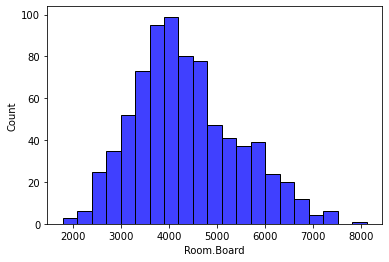

Distribution ofBooks


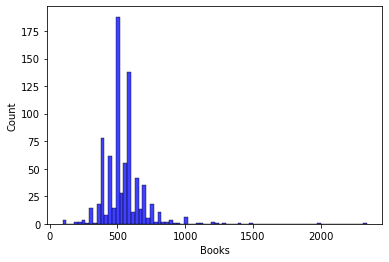

Distribution ofPersonal


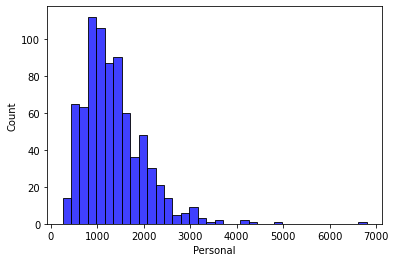

Distribution ofPhD


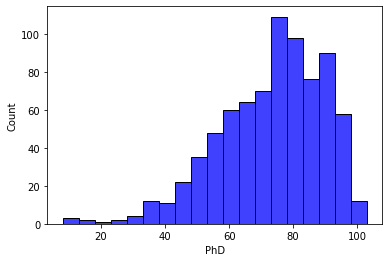

Distribution ofTerminal


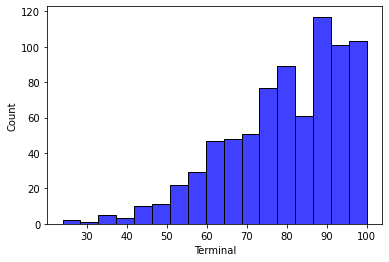

Distribution ofS.F.Ratio


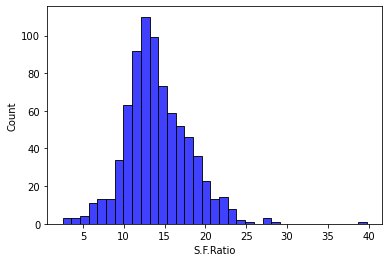

Distribution ofperc.alumni


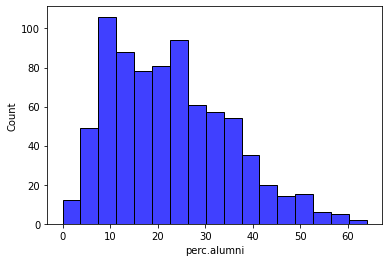

Distribution ofExpend


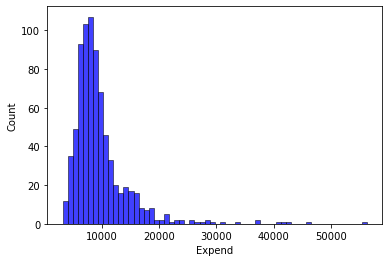

Distribution ofGrad.Rate


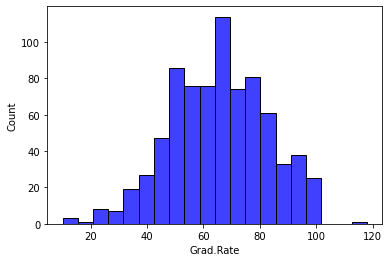

In [14]:
for x in numericcolumns:
    univariateanalysis_numeric(x,20)

**Insight:** Most variables (Apps, Accept, Enroll, F.Undergrad, P.Undergrad, Personal, Expend) are right-skewed. Top25perc, Room.Board, and S.F.Ratio are approximately normal. PhD and Terminal are left-skewed. This skew is a key reason scaling is needed before PCA.

### Exploratory Data Analysis — Multivariate (Correlation)

In [15]:
corr=df1_num.corr(method="pearson")

C:\Users\LENOVO~1\AppData\Local\Temp/ipykernel_4264/3975865749.py:1: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask=np.triu(np.ones_like(corr,dtype=np.bool))


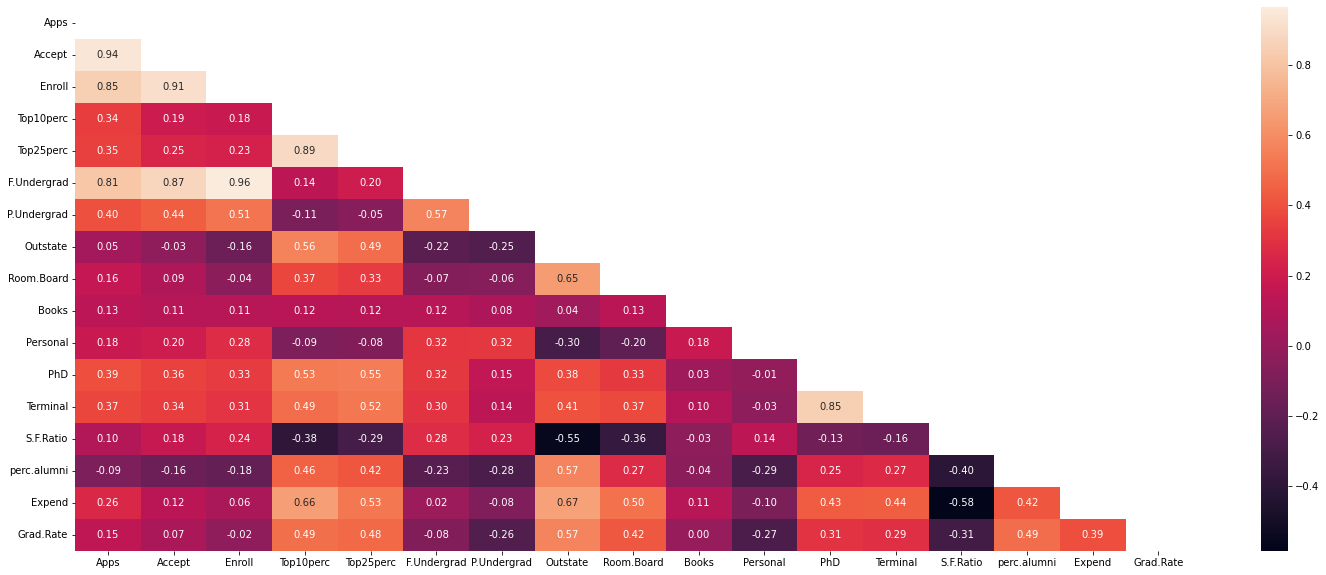

In [19]:
mask=np.triu(np.ones_like(corr,dtype=np.bool))
fig=plt.subplots(figsize=(25,10))
sns.heatmap(df1_num.corr(),annot=True,mask=mask,fmt=".2f")
plt.show()

**Insight:** Apps and Accept are highly correlated (0.94), as are F.Undergrad and Enroll (0.96/0.97). High multicollinearity among features like this is exactly what PCA is designed to address.

### Scaling

**Is scaling necessary?** Yes — feature values are on very different scales (e.g. Apps in the thousands, S.F.Ratio in single digits). Without scaling, high-magnitude features would dominate the PCA regardless of their actual variance/importance.

In [21]:
from scipy.stats import zscore
data_scaled=df1_num.apply(zscore)

In [22]:
data_scaled.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,-0.346882,-0.321205,-0.063509,-0.258583,-0.191827,-0.168116,-0.209207,-0.746356,-0.964905,-0.602312,1.270045,-0.163028,-0.115729,1.013776,-0.867574,-0.501910,-0.318252
1,-0.210884,-0.038703,-0.288584,-0.655656,-1.353911,-0.209788,0.244307,0.457496,1.909208,1.215880,0.235515,-2.675646,-3.378176,-0.477704,-0.544572,0.166110,-0.551262
2,-0.406866,-0.376318,-0.478121,-0.315307,-0.292878,-0.549565,-0.497090,0.201305,-0.554317,-0.905344,-0.259582,-1.204845,-0.931341,-0.300749,0.585935,-0.177290,-0.667767
3,-0.668261,-0.681682,-0.692427,1.840231,1.677612,-0.658079,-0.520752,0.626633,0.996791,-0.602312,-0.688173,1.185206,1.175657,-1.615274,1.151188,1.792851,-0.376504
4,-0.726176,-0.764555,-0.780735,-0.655656,-0.596031,-0.711924,0.009005,-0.716508,-0.216723,1.518912,0.235515,0.204672,-0.523535,-0.553542,-1.675079,0.241803,-2.939613


In [23]:
data_scaled.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02
mean,6.355797e-17,6.774575e-17,-5.249269e-17,-2.753232e-17,-1.546739e-16,-1.661405e-16,-3.029180e-17,6.515595e-17,3.570717e-16,-2.192583e-16,4.765243e-17,5.954768e-17,-4.481615e-16,-2.057556e-17,-6.022638e-17,1.213101e-16,3.886495e-16
std,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00
min,-7.551337e-01,-7.947645e-01,-8.022728e-01,-1.506526e+00,-2.364419e+00,-7.346169e-01,-5.615022e-01,-2.014878e+00,-2.351778e+00,-2.747779e+00,-1.611860e+00,-3.962596e+00,-3.785982e+00,-2.929799e+00,-1.836580e+00,-1.240641e+00,-3.230876e+00
25%,-5.754408e-01,-5.775805e-01,-5.793514e-01,-7.123803e-01,-7.476067e-01,-5.586426e-01,-4.997191e-01,-7.762035e-01,-6.939170e-01,-4.810994e-01,-7.251203e-01,-6.532948e-01,-5.915023e-01,-6.546598e-01,-7.868237e-01,-5.574826e-01,-7.260193e-01
50%,-3.732540e-01,-3.710108e-01,-3.725836e-01,-2.585828e-01,-9.077663e-02,-4.111378e-01,-3.301442e-01,-1.120949e-01,-1.437297e-01,-2.992802e-01,-2.078552e-01,1.433889e-01,1.561419e-01,-1.237939e-01,-1.408197e-01,-2.458933e-01,-2.698956e-02
75%,1.609122e-01,1.654173e-01,1.314128e-01,4.221134e-01,6.671042e-01,6.294077e-02,7.341765e-02,6.179271e-01,6.318245e-01,3.067838e-01,5.310950e-01,7.562224e-01,8.358184e-01,6.093067e-01,6.666852e-01,2.241735e-01,7.302926e-01
max,1.165867e+01,9.924816e+00,6.043678e+00,3.882319e+00,2.233391e+00,5.764674e+00,1.378992e+01,2.800531e+00,3.436593e+00,1.085230e+01,8.068387e+00,1.859323e+00,1.379560e+00,6.499390e+00,3.331452e+00,8.924721e+00,3.060392e+00


In [26]:
#creating df2 for data_scaled 
df2=pd.DataFrame(data_scaled)

In [27]:
df2.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,-0.346882,-0.321205,-0.063509,-0.258583,-0.191827,-0.168116,-0.209207,-0.746356,-0.964905,-0.602312,1.270045,-0.163028,-0.115729,1.013776,-0.867574,-0.501910,-0.318252
1,-0.210884,-0.038703,-0.288584,-0.655656,-1.353911,-0.209788,0.244307,0.457496,1.909208,1.215880,0.235515,-2.675646,-3.378176,-0.477704,-0.544572,0.166110,-0.551262
2,-0.406866,-0.376318,-0.478121,-0.315307,-0.292878,-0.549565,-0.497090,0.201305,-0.554317,-0.905344,-0.259582,-1.204845,-0.931341,-0.300749,0.585935,-0.177290,-0.667767
3,-0.668261,-0.681682,-0.692427,1.840231,1.677612,-0.658079,-0.520752,0.626633,0.996791,-0.602312,-0.688173,1.185206,1.175657,-1.615274,1.151188,1.792851,-0.376504
4,-0.726176,-0.764555,-0.780735,-0.655656,-0.596031,-0.711924,0.009005,-0.716508,-0.216723,1.518912,0.235515,0.204672,-0.523535,-0.553542,-1.675079,0.241803,-2.939613


### Covariance vs. Correlation Matrix (scaled data)

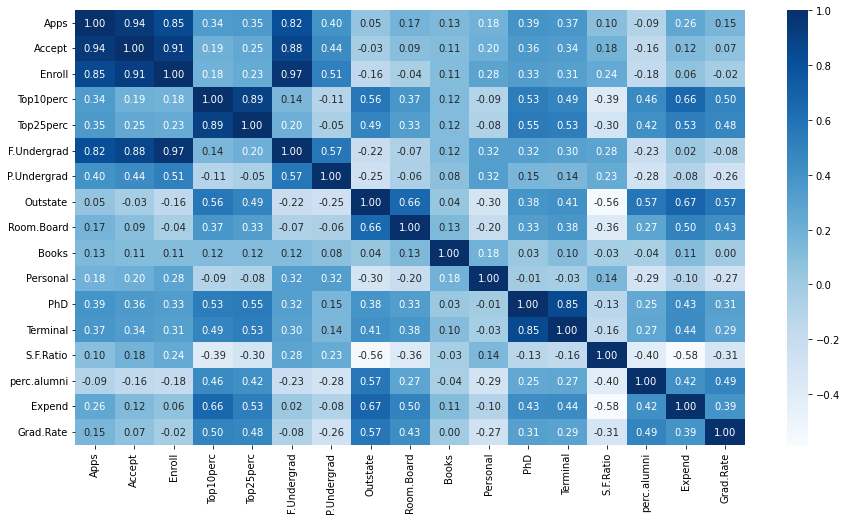

In [74]:
#covariance matrix
covMatrix=pd.DataFrame.cov(df2)
fig=plt.subplots(figsize=(15,8))
sns.heatmap(covMatrix,annot=True,fmt=".2f",cmap="Blues")
plt.show()

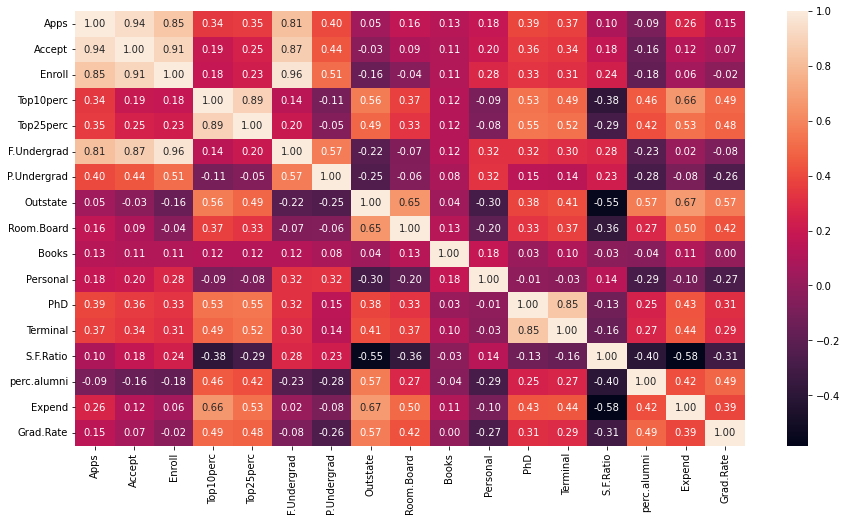

In [71]:
#correlation matrix
corrMatrix=df2.corr()
fig=plt.subplots(figsize=(15,8))
sns.heatmap(corrMatrix,annot=True,fmt=".2f")
plt.show()

**Insight:** On scaled (z-scored) data, the covariance and correlation matrices produce identical results — this is expected, since scaling to unit variance makes covariance equivalent to correlation.

### Outlier Check (before vs. after scaling)

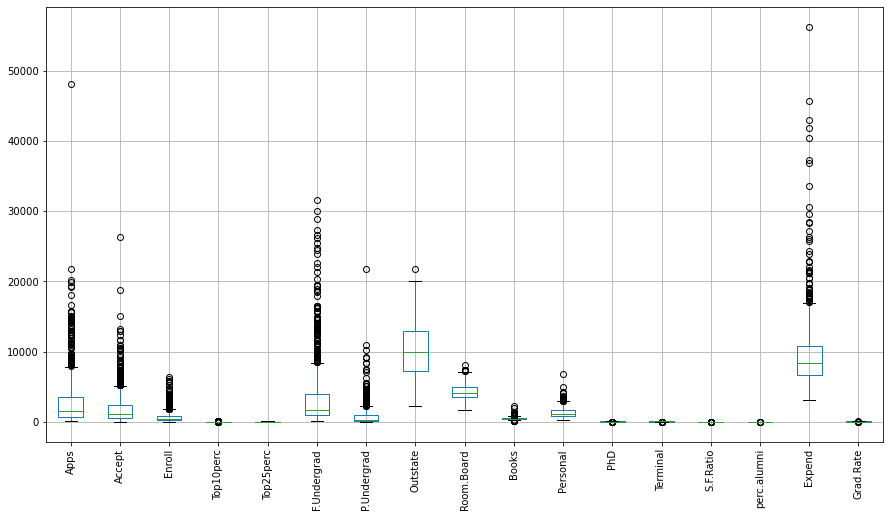

In [37]:
#checking for outliers before scaling
df1_num.boxplot(figsize=(15,8))
plt.xticks(rotation=90)
plt.show()

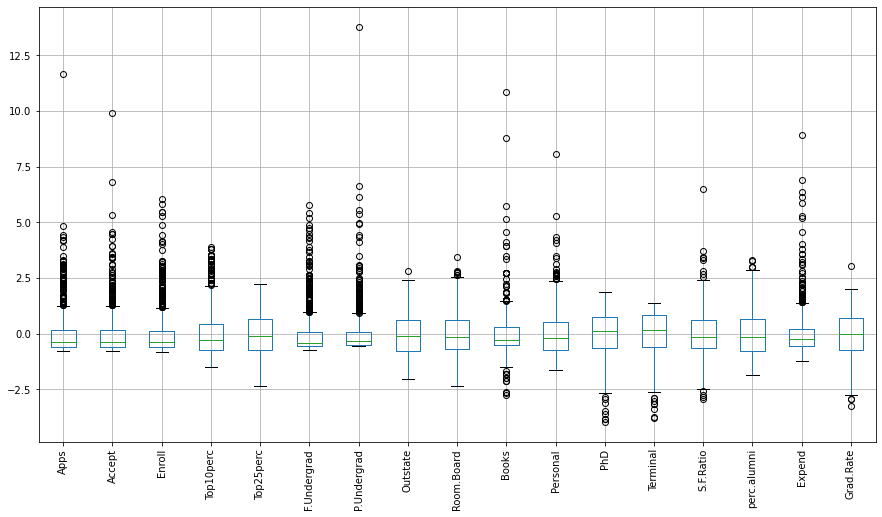

In [38]:
#checking for outliers after scaling
df2.boxplot(figsize=(15,8))
plt.xticks(rotation=90)
plt.show()

**Insight:** Outliers persist in the data even after scaling — scaling shrinks the *range* of each variable but does not remove outliers. Outlier treatment (if needed) is a separate step from scaling.

### Principal Component Analysis

In [39]:
from sklearn.decomposition import PCA

In [41]:
pca=PCA(n_components=17,random_state=123)
pca_transformed=pca.fit_transform(df2)

**Eigenvectors** — direction of each principal component in the original 17-feature space:

In [42]:
#eigen vectors
pca.components_

array([[ 2.48765602e-01,  2.07601502e-01,  1.76303592e-01,
         3.54273947e-01,  3.44001279e-01,  1.54640962e-01,
         2.64425045e-02,  2.94736419e-01,  2.49030449e-01,
         6.47575181e-02, -4.25285386e-02,  3.18312875e-01,
         3.17056016e-01, -1.76957895e-01,  2.05082369e-01,
         3.18908750e-01,  2.52315654e-01],
       [ 3.31598227e-01,  3.72116750e-01,  4.03724252e-01,
        -8.24118211e-02, -4.47786551e-02,  4.17673774e-01,
         3.15087830e-01, -2.49643522e-01, -1.37808883e-01,
         5.63418434e-02,  2.19929218e-01,  5.83113174e-02,
         4.64294477e-02,  2.46665277e-01, -2.46595274e-01,
        -1.31689865e-01, -1.69240532e-01],
       [-6.30921033e-02, -1.01249056e-01, -8.29855709e-02,
         3.50555339e-02, -2.41479376e-02, -6.13929764e-02,
         1.39681716e-01,  4.65988731e-02,  1.48967389e-01,
         6.77411649e-01,  4.99721120e-01, -1.27028371e-01,
        -6.60375454e-02, -2.89848401e-01, -1.46989274e-01,
         2.26743985e-01, -2.0

**Eigenvalues** — how much variance each component explains:

In [43]:
#eigen values
pca.explained_variance_

array([5.45052162, 4.48360686, 1.17466761, 1.00820573, 0.93423123,
       0.84849117, 0.6057878 , 0.58787222, 0.53061262, 0.4043029 ,
       0.31344588, 0.22061096, 0.16779415, 0.1439785 , 0.08802464,
       0.03672545, 0.02302787])

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Apps         777 non-null    float64
 1   Accept       777 non-null    float64
 2   Enroll       777 non-null    float64
 3   Top10perc    777 non-null    float64
 4   Top25perc    777 non-null    float64
 5   F.Undergrad  777 non-null    float64
 6   P.Undergrad  777 non-null    float64
 7   Outstate     777 non-null    float64
 8   Room.Board   777 non-null    float64
 9   Books        777 non-null    float64
 10  Personal     777 non-null    float64
 11  PhD          777 non-null    float64
 12  Terminal     777 non-null    float64
 13  S.F.Ratio    777 non-null    float64
 14  perc.alumni  777 non-null    float64
 15  Expend       777 non-null    float64
 16  Grad.Rate    777 non-null    float64
dtypes: float64(17)
memory usage: 103.3 KB


In [53]:
#exporting pca to dataframe
df_pca=pd.DataFrame(pca.components_.T,columns=["PC1","PC2",'PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10','PC11','PC12','PC13','PC14','PC15','PC16','PC17'],index=df2.columns)


In [54]:

df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
Apps,0.248766,0.331598,-0.063092,0.281311,0.005741,-0.016237,-0.042486,-0.103090,-0.090227,0.052510,0.043046,0.024071,0.595831,0.080633,0.133406,0.459139,0.358970
Accept,0.207602,0.372117,-0.101249,0.267817,0.055786,0.007535,-0.012950,-0.056271,-0.177865,0.041140,-0.058406,-0.145102,0.292642,0.033467,-0.145498,-0.518569,-0.543427
Enroll,0.176304,0.403724,-0.082986,0.161827,-0.055694,-0.042558,-0.027693,0.058662,-0.128561,0.034488,-0.069399,0.011143,-0.444638,-0.085697,0.029590,-0.404318,0.609651
Top10perc,0.354274,-0.082412,0.035056,-0.051547,-0.395434,-0.052693,-0.161332,-0.122678,0.341100,0.064026,-0.008105,0.038554,0.001023,-0.107828,0.697723,-0.148739,-0.144986
Top25perc,0.344001,-0.044779,-0.024148,-0.109767,-0.426534,0.033092,-0.118486,-0.102492,0.403712,0.014549,-0.273128,-0.089352,0.021884,0.151742,-0.617275,0.051868,0.080348
F.Undergrad,0.154641,0.417674,-0.061393,0.100412,-0.043454,-0.043454,-0.025076,0.078890,-0.059442,0.020847,-0.081158,0.056177,-0.523622,-0.056373,0.009916,0.560363,-0.414705
P.Undergrad,0.026443,0.315088,0.139682,-0.158558,0.302385,-0.191199,0.061042,0.570784,0.560673,-0.223106,0.100693,-0.063536,0.125998,0.019286,0.020952,-0.052731,0.009018
Outstate,0.294736,-0.249644,0.046599,0.131291,0.222532,-0.030000,0.108529,0.009846,-0.004573,0.186675,0.143221,-0.823444,-0.141856,-0.034012,0.038354,0.101595,0.050900
Room.Board,0.249030,-0.137809,0.148967,0.184996,0.560919,0.162755,0.209744,-0.221453,0.275023,0.298324,-0.359322,0.354560,-0.069749,-0.058429,0.003402,-0.025929,0.001146
Books,0.064758,0.056342,0.677412,0.087089,-0.127289,0.641055,-0.149692,0.213293,-0.133663,-0.082029,0.031940,-0.028159,0.011438,-0.066849,-0.009439,0.002883,0.000773


**First Principal Component (PC1), explicit form:**

PC1 = 0.25·Apps + 0.21·Accept + 0.18·Enroll + 0.35·Top10perc + 0.34·Top25perc + 0.15·F.Undergrad + 0.03·P.Undergrad + 0.30·Outstate + 0.25·Room.Board + 0.06·Books − 0.04·Personal + 0.32·PhD + 0.32·Terminal − 0.18·S.F.Ratio + 0.21·perc.alumni + 0.32·Expend + 0.25·Grad.Rate

**Explained variance ratio** per component:

In [55]:
#finding explained variance ratio
pca.explained_variance_ratio_

array([0.32020628, 0.26340214, 0.06900917, 0.05922989, 0.05488405,
       0.04984701, 0.03558871, 0.03453621, 0.03117234, 0.02375192,
       0.01841426, 0.01296041, 0.00985754, 0.00845842, 0.00517126,
       0.00215754, 0.00135284])

### Scree Plot — Choosing the Number of Components

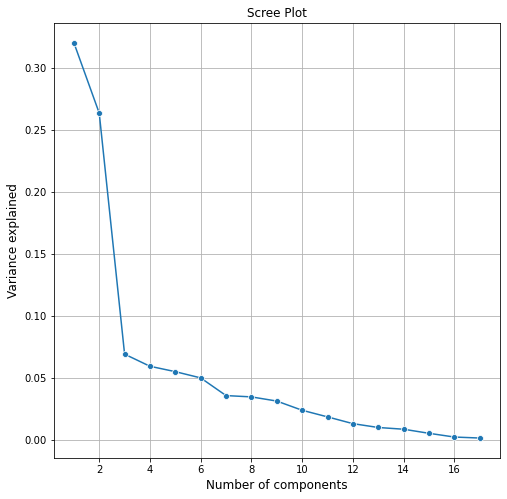

In [58]:
#creating a scree plot 
plt.figure(figsize=(8,8))
sns.lineplot(y=pca.explained_variance_ratio_,x=range(1,18),marker="o")
plt.xlabel("Number of components",fontsize=12)
plt.ylabel("Variance explained",fontsize=12)
plt.title("Scree Plot",fontsize=12)
plt.grid()
plt.show()

**Cumulative explained variance:**

In [59]:
#checking the cumulative explained variane ratio
np.cumsum(pca.explained_variance_ratio_)

array([0.32020628, 0.58360843, 0.65261759, 0.71184748, 0.76673154,
       0.81657854, 0.85216726, 0.88670347, 0.91787581, 0.94162773,
       0.96004199, 0.9730024 , 0.98285994, 0.99131837, 0.99648962,
       0.99864716, 1.        ])

**Decision:** The first 7 principal components together capture ~85% of the total variance — a reasonable cutoff for dimensionality reduction (down from 17 original features to 7 components).

In [60]:
#choosing the PCs based on cumulative explained variance
df1_selected=df_pca[["PC1","PC2",'PC3','PC4','PC5','PC6','PC7']]

In [61]:
df1_selected

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Apps,0.248766,0.331598,-0.063092,0.281311,0.005741,-0.016237,-0.042486
Accept,0.207602,0.372117,-0.101249,0.267817,0.055786,0.007535,-0.012950
Enroll,0.176304,0.403724,-0.082986,0.161827,-0.055694,-0.042558,-0.027693
Top10perc,0.354274,-0.082412,0.035056,-0.051547,-0.395434,-0.052693,-0.161332
Top25perc,0.344001,-0.044779,-0.024148,-0.109767,-0.426534,0.033092,-0.118486
F.Undergrad,0.154641,0.417674,-0.061393,0.100412,-0.043454,-0.043454,-0.025076
P.Undergrad,0.026443,0.315088,0.139682,-0.158558,0.302385,-0.191199,0.061042
Outstate,0.294736,-0.249644,0.046599,0.131291,0.222532,-0.030000,0.108529
Room.Board,0.249030,-0.137809,0.148967,0.184996,0.560919,0.162755,0.209744
Books,0.064758,0.056342,0.677412,0.087089,-0.127289,0.641055,-0.149692


---
## Key Findings & Business Implications

**ANOVA (Problem 1):**
- Education has a statistically significant effect on salary (p < 0.05); Occupation alone does not (p = 0.459).
- However, Education × Occupation has a significant interaction effect (p < 0.05) — salary depends on the *combination* of the two, not either factor in isolation.
- **Implication:** Compensation planning should account for education-occupation combinations rather than either factor alone.

**PCA (Problem 2):**
- 17 correlated numeric features were reduced to 7 principal components while retaining ~85% of the variance.
- PC1 is most strongly driven by Top10perc, Top25perc, PhD, Terminal, and Expend — broadly, a college's academic selectivity and spending profile.
- **Implication:** These 7 components can now be used as decorrelated inputs for further modelling (e.g. clustering colleges by profile, or regression on graduation rate) without the multicollinearity present in the raw 17 features.